# **One-Hot Encoding in NLP**
In one-hot encoding each unique word is mapped to a binary vector where only one position has the value 1 and all others are 0. The length of the vector equals the size of the vocabulary making each word uniquely identifiable.

- Transforms categorical text data into numeric vectors
- Each word is represented by a vector with a single 1 and remaining 0s
- Easy to understand and implement
- Works well for small vocabularies but becomes inefficient for large ones

In [2]:
import numpy as np
import string
import matplotlib.pyplot as plt

### **Define the Corpus**

- A corpus is a collection of sentences on which we want to perform NLP tasks.
- Each sentence will later be tokenized and encoded.

In [3]:
corpus = [
    "The quick brown fox jumps over the lazy dog",
    "The dog chased the fox",
    "The fox is quick and smart"
]

### **Preprocess Text**

- Convert text to lowercase to maintain consistency.
- Remove punctuation to avoid treating punctuations as separate tokens.
- Split the sentence into individual words.

In [4]:
def preprocess_text(text):
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    return text.split()
tokenized_corpus = [preprocess_text(sentence) for sentence in corpus]
print(tokenized_corpus)

[['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog'], ['the', 'dog', 'chased', 'the', 'fox'], ['the', 'fox', 'is', 'quick', 'and', 'smart']]


### **Build Vocabulary**

- A vocabulary contains all unique words across the corpus.
- Sorting helps maintain a consistent order.
- We also create a dictionary to map each word to a unique index.

In [5]:
vocabulary = sorted(set(word for sentence in tokenized_corpus for word in sentence))
word_to_index = {word: idx for idx, word in enumerate(vocabulary)}
print(word_to_index)

{'and': 0, 'brown': 1, 'chased': 2, 'dog': 3, 'fox': 4, 'is': 5, 'jumps': 6, 'lazy': 7, 'over': 8, 'quick': 9, 'smart': 10, 'the': 11}


### **One-Hot Encode Sentences**

- For each word create a zero vector of length equal to vocabulary size.
- Set the index corresponding to the word to 1.
- Collect all word vectors for a sentence.

In [6]:
def one_hot_encode(sentence, word_to_index):
    vocab_size = len(word_to_index)
    encoded_sentence = []
    for word in sentence:
        vector = np.zeros(vocab_size, dtype=int)
        vector[word_to_index[word]] = 1
        encoded_sentence.append(vector)
    return np.array(encoded_sentence)
encoded_vectors = one_hot_encode(tokenized_corpus[0], word_to_index)
print(encoded_vectors)

[[0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 1 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0]]


In [7]:
print("Vocabulary:")
print(vocabulary)

print("\nOne-Hot Encoded Vectors (First Sentence):")
for word, vector in zip(tokenized_corpus[0], encoded_vectors):
    print(f"{word}: {vector}")

Vocabulary:
['and', 'brown', 'chased', 'dog', 'fox', 'is', 'jumps', 'lazy', 'over', 'quick', 'smart', 'the']

One-Hot Encoded Vectors (First Sentence):
the: [0 0 0 0 0 0 0 0 0 0 0 1]
quick: [0 0 0 0 0 0 0 0 0 1 0 0]
brown: [0 1 0 0 0 0 0 0 0 0 0 0]
fox: [0 0 0 0 1 0 0 0 0 0 0 0]
jumps: [0 0 0 0 0 0 1 0 0 0 0 0]
over: [0 0 0 0 0 0 0 0 1 0 0 0]
the: [0 0 0 0 0 0 0 0 0 0 0 1]
lazy: [0 0 0 0 0 0 0 1 0 0 0 0]
dog: [0 0 0 1 0 0 0 0 0 0 0 0]


# **Bag of Words (BoW) model**
The Bag of Words (BoW) model is a simple and commonly used method for this purpose.
- Converts text (sentence, paragraph, or document) into a collection of words
- Counts how often each word appears in the text
- Ignores word order and grammar, focusing only on frequency

In [35]:
import nltk
import re
import heapq
import pandas as pd
import numpy as np
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns

### **Preprocessing the Text**

Before applying the BoW model, we need to preprocess the text. This includes:

- Converting the text to lowercase
- Removing non-word characters
- Removing extra spaces

In [10]:
text = """Beans. I was trying to explain to somebody as we were flying in, that's corn.
         That's beans. And they were very impressed at my agricultural knowledge. 
         Please give it up for Amaury once again for that outstanding introduction. 
         I have a bunch of good friends here today, including somebody who I served with, 
         who is one of the finest senators in the country, and we're lucky to have him, 
         your Senator, Dick Durbin is here. I also noticed, by the way, 
         former Governor Edgar here, who I haven't seen in a long time, and 
         somehow he has not aged and I have. And it's great to see you, Governor. 
         I want to thank President Killeen and everybody at the U of I System for 
         making it possible for me to be here today. And I am deeply honored at the Paul 
         Douglas Award that is being given to me. He is somebody who set the path for so 
         much outstanding public service here in Illinois. Now, I want to start by 
         addressing the elephant in the room. I know people are still wondering why 
         I didn't speak at the commencement."""

dataset = nltk.sent_tokenize(text)

for i in range(len(dataset)):
    dataset[i] = dataset[i].lower()
    dataset[i] = re.sub(r'\W', ' ', dataset[i])
    dataset[i] = re.sub(r'\s+', ' ', dataset[i])

for i, sentence in enumerate(dataset):
    print(f"Sentence {i+1}: {sentence}")

Sentence 1: beans 
Sentence 2: i was trying to explain to somebody as we were flying in that s corn 
Sentence 3: that s beans 
Sentence 4: and they were very impressed at my agricultural knowledge 
Sentence 5: please give it up for amaury once again for that outstanding introduction 
Sentence 6: i have a bunch of good friends here today including somebody who i served with who is one of the finest senators in the country and we re lucky to have him your senator dick durbin is here 
Sentence 7: i also noticed by the way former governor edgar here who i haven t seen in a long time and somehow he has not aged and i have 
Sentence 8: and it s great to see you governor 
Sentence 9: i want to thank president killeen and everybody at the u of i system for making it possible for me to be here today 
Sentence 10: and i am deeply honored at the paul douglas award that is being given to me 
Sentence 11: he is somebody who set the path for so much outstanding public service here in illinois 
Sente

### **Counting Word Frequencies**

In this step, we count the frequency of each word in the preprocessed text. We will store these counts in a pandas DataFrame to view them easily in a tabular format.

- We initialize a dictionary to hold our word counts.
- Then, we tokenize each sentence into words.
- For each word, we check if it exists in our dictionary. If it does, we increment its count. If it doesn’t, we add it to the dictionary with a count of 1.

In [12]:
word2count = {}

for data in dataset:
    words = nltk.word_tokenize(data)
    for word in words:
        if word not in word2count:
            word2count[word] = 1
        else:
            word2count[word] += 1

stop_words = set(stopwords.words('english'))
filtered_word2count = {word: count for word, count in word2count.items() if word not in stop_words}
word_freq_df = pd.DataFrame(list(filtered_word2count.items()), columns=['Word', 'Frequency'])
word_freq_df = word_freq_df.sort_values(by='Frequency', ascending=False)
print(word_freq_df)

            Word  Frequency
3       somebody          3
0          beans          2
12   outstanding          2
41          want          2
17         today          2
..           ...        ...
31        former          1
33         edgar          1
34          seen          1
35          long          1
71  commencement          1

[72 rows x 2 columns]


### **Selecting the Most Frequent Words**

Now that we have counted the word frequencies, we will select the top N most frequent words (e.g top 10) to be used in the BoW model. 

Top 10 frequent words: ['i', 'the', 'to', 'and', 'in', 'for', 'here', 'that', 'at', 'who']


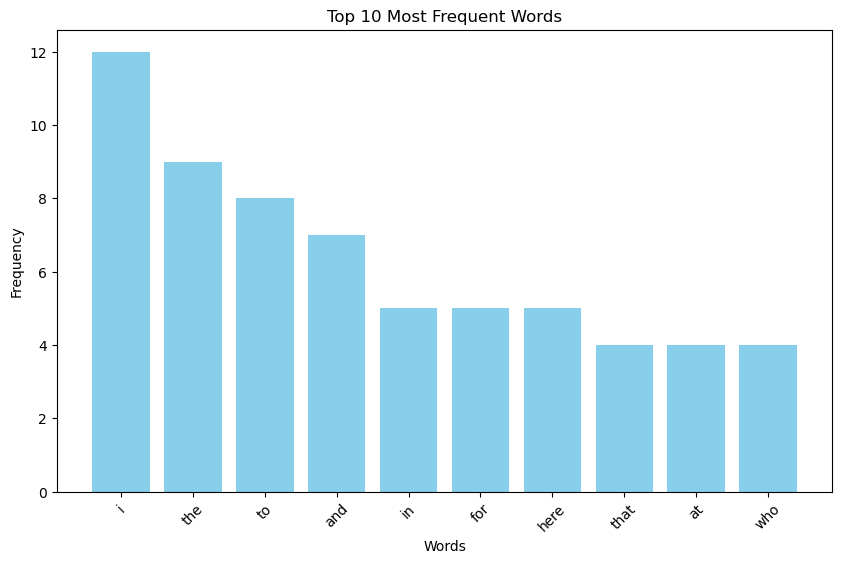

In [29]:
freq_words = heapq.nlargest(10, word2count, key=word2count.get)
print(f"Top 10 frequent words: {freq_words}")

top_words = sorted(word2count.items(), key=lambda x: x[1], reverse=True)[:10]
words, counts = zip(*top_words)

plt.figure(figsize=(10, 6))
plt.bar(words, counts, color='skyblue')
plt.xticks(rotation=45)
plt.title('Top 10 Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

### **Building the Bag of Words (BoW) Model**

This model is represented as a binary matrix where each row corresponds to a sentence and each column represents one of the top N frequent words. A 1 in the matrix shows that the word is present in the sentence and a 0 shows its absence.

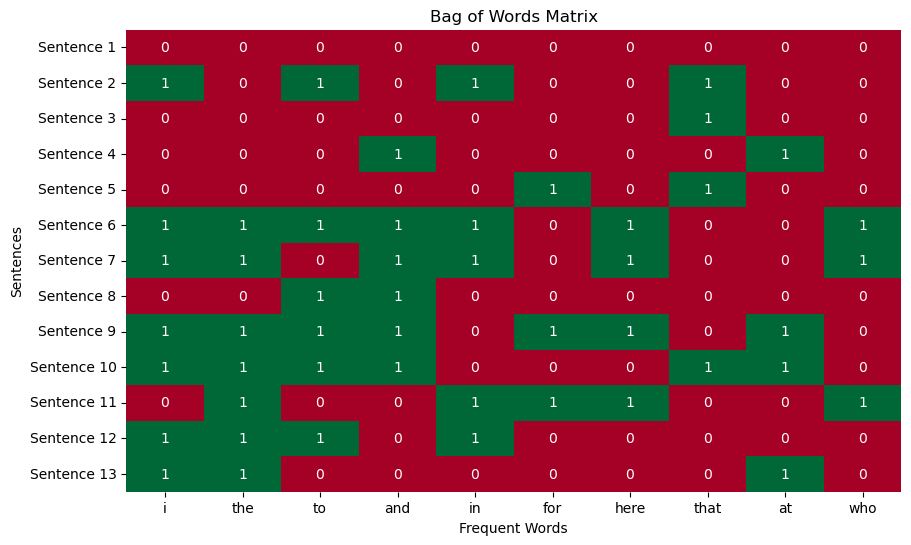

In [30]:
X = []

for data in dataset:
    vector = []
    for word in freq_words:
        if word in nltk.word_tokenize(data):
            vector.append(1)
        else:
            vector.append(0)
    X.append(vector)

X = np.asarray(X)

plt.figure(figsize=(10, 6))
sns.heatmap(X, cmap='RdYlGn',
            cbar=False,
            annot=True,
            fmt="d",
            xticklabels=freq_words,
            yticklabels=[f"Sentence {i+1}" for i in range(len(dataset))])

plt.title('Bag of Words Matrix')
plt.xlabel('Frequent Words')
plt.ylabel('Sentences')
plt.show()

# **TF-IDF (Term Frequency-Inverse Document Frequency)**
TF-IDF (Term Frequency–Inverse Document Frequency) is a statistical method used in natural language processing and information retrieval to evaluate how important a word is to a document in relation to a larger collection of documents. TF-IDF combines two components:

**1. Term Frequency (TF):** Measures how often a word appears in a document. A higher frequency suggests greater importance. If a term appears frequently in a document, it is likely relevant to the document’s content.

### TF=Total words in document/Number of times term appears in document\

**2. Inverse Document Frequency (IDF):** Reduces the weight of common words across multiple documents while increasing the weight of rare words. If a term appears in fewer documents, it is more likely to be meaningful and specific.

### IDF=log(N/df)

This balance allows TF-IDF to highlight terms that are both frequent within a specific document and distinctive across the text document, making it a useful tool for tasks like search ranking, text classification and keyword extraction.

### TF-IDF = Term Frequency (TF) × Inverse Document Frequency (IDF)

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [37]:
d0 = "The cat sat on the mat."
d1 = "The dog played in the park."
d2 = "Cats and dogs are great pets."
string = [d0, d1, d2]

In [38]:
tfidf = TfidfVectorizer()
result = tfidf.fit_transform(string)

In [39]:
print('\nidf values:')
for ele1, ele2 in zip(tfidf.get_feature_names_out(), tfidf.idf_):
    print(ele1, ':', ele2)


idf values:
and : 1.6931471805599454
are : 1.6931471805599454
cat : 1.6931471805599454
cats : 1.6931471805599454
dog : 1.6931471805599454
dogs : 1.6931471805599454
great : 1.6931471805599454
in : 1.6931471805599454
mat : 1.6931471805599454
on : 1.6931471805599454
park : 1.6931471805599454
pets : 1.6931471805599454
played : 1.6931471805599454
sat : 1.6931471805599454
the : 1.2876820724517808


In [40]:
print('\nWord indexes:')
print(tfidf.vocabulary_)
print('\ntf-idf value:')
print(result)
print('\ntf-idf values in matrix form:')
print(result.toarray())


Word indexes:
{'the': 14, 'cat': 2, 'sat': 13, 'on': 9, 'mat': 8, 'dog': 4, 'played': 12, 'in': 7, 'park': 10, 'cats': 3, 'and': 0, 'dogs': 5, 'are': 1, 'great': 6, 'pets': 11}

tf-idf value:
  (0, 14)	0.6053485081062916
  (0, 2)	0.3979802707840826
  (0, 13)	0.3979802707840826
  (0, 9)	0.3979802707840826
  (0, 8)	0.3979802707840826
  (1, 14)	0.6053485081062916
  (1, 4)	0.3979802707840826
  (1, 12)	0.3979802707840826
  (1, 7)	0.3979802707840826
  (1, 10)	0.3979802707840826
  (2, 3)	0.40824829046386296
  (2, 0)	0.40824829046386296
  (2, 5)	0.40824829046386296
  (2, 1)	0.40824829046386296
  (2, 6)	0.40824829046386296
  (2, 11)	0.40824829046386296

tf-idf values in matrix form:
[[0.         0.         0.39798027 0.         0.         0.
  0.         0.         0.39798027 0.39798027 0.         0.
  0.         0.39798027 0.60534851]
 [0.         0.         0.         0.         0.39798027 0.
  0.         0.39798027 0.         0.         0.39798027 0.
  0.39798027 0.         0.60534851]
 [0.